# Moment-Curvature

A moment-curvature analysis is performed using a uniaxial fiber section.

The geometry of the section is depicted below:

![](/_static/images/gallery/fiber-0004-46f03605.png)

## Materials

In [1]:

import xara
from xara.units.iks import inch, foot, ksi, kip 

Fy = 60*ksi
Es = 29e3*ksi
# Define materials
materials = {
    "core": xara.UniaxialMaterial(
        type = "Concrete01",
        Fc  =  6*ksi,
        nu  =  0.2,
        ec0 =  0.004,
        Fcu =  5*ksi,
        ecu =  0.014
    ),
    "cover": xara.UniaxialMaterial(
        type = "Concrete01",
        Fc  =  -5*ksi,
        nu  =   0.2,
        ec0 =  -0.002,
        Fcu =  -0.0*ksi,
        ecu =  -0.006,
        # "lambda": 0.1,
        # "Ft": 0.65*ksi,
        # "Ets": 500. # Tension stiffening
    ),
    "rebar": xara.UniaxialMaterial(
        type = "Steel01",
        nu = 0.3,
        E  =   29e3*ksi,
        Fy =     60*ksi,
        b =   0.01
    )
}


## Geometry

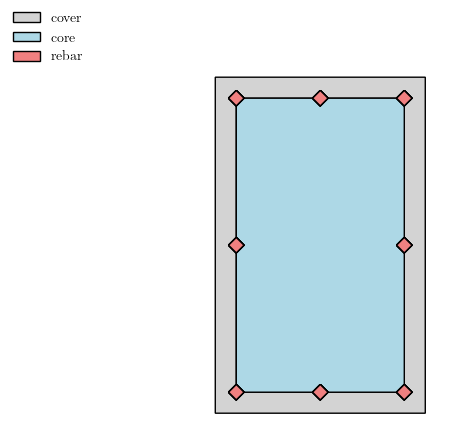

In [2]:
import veux
from xsection import CompositeSection
from xsection.library import Circle, Rectangle
import matplotlib.pyplot as plt
import numpy as np

# Define cross-section
# ------------------------------------------
# set some parameters
b = width = 15.0
h = depth = 24.0
c = cover = 1.5
As = 0.60;     # area of no. 7 bars
r = 7/16;      # radius of rebar

bar = Circle(radius=7/16, 
             z=2, 
             material=materials["rebar"], 
             group="rebar", 
             divisions=4, 
             mesh_scale=1/2)

# some variables derived from the parameters
y1 = depth/2.0
z1 = width/2.0

shape = CompositeSection([
    Rectangle(    b, h,     z=0, group="cover", material=materials["cover"]),
    Rectangle(b-2*c, h-2*c, z=1, group="core", material=materials["core"]),
    *bar.linspace([-b/2+c, -h/2+c], [ b/2-c,-h/2+c], 3), # Top bars
    *bar.linspace([-b/2+c,      0], [ b/2-c,     0], 2), # Center bars
    *bar.linspace([-b/2+c,  h/2-c], [ b/2-c, h/2-c], 3)  # Bottom bars
])


# fibers = [
#             *bar.linspace([-b/2+c+r, -h/2+c+r], [ b/2-c-r,-h/2+c+r], 3), # Top bars
#             *bar.linspace([-b/2+c+r,        0], [ b/2-c-r,       0], 2), # Center bars
#             *bar.linspace([-b/2+c+r,  h/2-c-r], [ b/2-c-r, h/2-c-r], 3)  # Bottom bars
# ]
# for fiber in fibers:
#     artist.ax.plot(fiber.centroid[0], fiber.centroid[1], "ro")
veux.draw_shape(shape)

## Analysis

A {ref}`ZeroLengthSection <zeroLengthSection>` element is used.

In [3]:

def moment_curvature(shape, axialLoad, maxK, numIncr, y=None):
    """
    Arguments
       secTag -- tag identifying section to be analyzed
       axialLoad -- axial load applied to section (negative is compression)
       maxK -- maximum curvature reached during analysis
       numIncr -- number of increments used to reach maxK (default 100)
    """
    model = xara.Model(ndm=3, ndf=6)

    # Define two nodes at (0,0)
    model.node(1, (0.0, 0.0, 0))
    model.node(2, (0.0, 0.0, 0))

    # Fix all degrees of freedom except axial and bending
    model.fix(1, (1, 1, 1, 1, 1, 1))
    model.fix(2, (0, 1, 1, 1, 0, 1))

    # Define materials
    for material in materials.values():
        model.material(material)

    # Define section

    section = xara.Section("Fiber", shape)

    model.section(section)

    # Define element
    x = (1.0, 0.0, 0.0)
    if y is None:
        y = (0.0, 1.0, 0.0)
    model.element("ZeroLengthSection", 1, (1, 2), section, y=y, x=x)


    # Define constant axial load
    model.pattern("Plain", 1, "Constant", 
                  loads={2: [axialLoad, 0.0, 0.0, 0, 0, 0]}
    )

    #
    # Define analysis
    #
    model.system("BandGeneral")
    model.numberer("Plain")
    model.constraints("Plain")
    model.test("NormUnbalance", 1.0e-10, 10)
    model.algorithm("Newton")
    model.integrator("LoadControl", 0.0)
    model.analysis("Static")

    # Do one analysis for constant axial load
    model.analyze(1)

    # Define reference moment
    model.pattern("Plain", 2, "Linear")
    model.load(2, (0, 0, 0, 0.0, 1.0, 0.0), pattern=2)

    # Compute curvature increment
    dK = maxK/numIncr

    # Use displacement control at node 2 for section analysis
    model.integrator("DisplacementControl", 2, 5, dK)

    # Do the section analysis
    M,K = [0], [0]
    for i in range(numIncr):
        status = model.analyze(1)
        if status != 0:
            print(f"Analysis failed at step {i}")
            break
        else:
            K.append(model.nodeDisp(2, 5))
            M.append(model.getTime())

    return K,M



In [4]:

P   =  -180.0   # Axial load
mu  =    32.0   # Target ductility for analysis
numIncr = 200   # Number of analysis increments


# Estimate yield curvature
# (Assuming no axial load and only top and bottom steel)
d = depth - cover   # d -- from cover to rebar
epsy = Fy/Es # steel yield strain
Ky = epsy/(0.7*d)
Kz = epsy/(0.7*b)


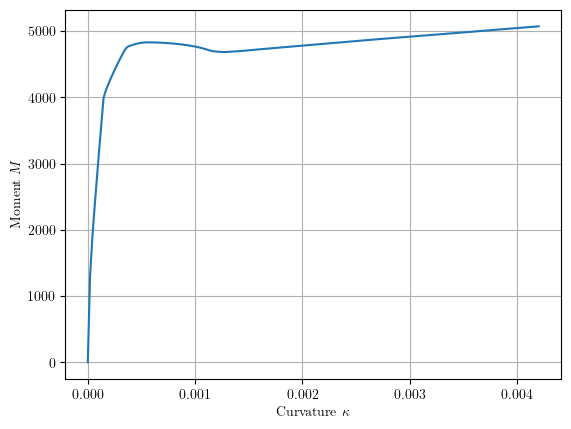

In [5]:

K, M = moment_curvature(shape, P, Ky*mu, numIncr)
plt.plot(K, M)
plt.grid(True)
plt.xlabel("Curvature $\\kappa$")
plt.ylabel("Moment $M$");

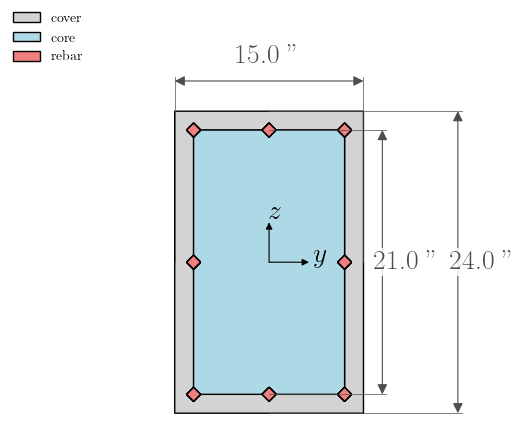

In [ ]:
# artist = veux.ShapeArtist(shape)
# artist.draw_exterior()
# artist.draw_surfaces()
artist = veux.draw_shape(shape)
artist.draw_origin(label=("$y$","$z$"), fontsize=20)
artist.draw_dimensions({
    f"{h} \"":     (((0, -h/2), (0, h/2)), (b, 0), "inside"),
    f"{h-2*c} \"":   (((0, -(h/2-c)), (0, h/2-c)),  (b*0.6,  0), "inside"),
    f"{b} \"":     (((-b/2, 0), (b/2, 0)), (0, h*0.6), "inside")
}, gap=1,fontsize=20)
# artist.ax.figure.savefig("/_static/images/gallery/fiber-0004-46f03605.png", dpi=300)